# Notebook 4 — Modeling & Evaluation

**Goal**: 
- Train two models (LR + XGBoost), compare AUC/Gini, calibrate,
<br>select winner then try to make it better, and also show feature importance for baseline and tuned model.

## import libraries

In [ ]:
#  Imports
import pandas as pd
import joblib
import json
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import xgboost as xgb
import warnings
import numpy as np
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import brier_score_loss
import sys, os

# Add project / to path , try to change to ../src in path below if running this creates error 
sys.path.insert(0, os.path.abspath('../'))

from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

from src.utils.config import (
    PATHS, TARGET_COL, RANDOM_STATE,
    XGB_CATEGORICAL_COLS, CATEGORICAL_FEATURES, CONTINUOUS_FEATURES, LEAKAGE_COLUMNS
)
from src.utils.evaluation import (
    report_auc, report_auc_all, model_comparison_table,
    fit_platt_scaling, fit_isotonic,
    apply_platt, apply_isotonic,
    hosmer_lemeshow_test,
    plot_calibration_raw, plot_calibration_comparison,plot_roc_comparison,
    lr_coefficient_table, xgb_importance_table, plot_feature_importance,
)


# 1. Import Data

In [3]:
final_dir = PATHS['final_dir']

# --- LR path: WoE-transformed features ---
X_train_woe = pd.read_parquet(final_dir / 'X_train_woe_tree.parquet')
X_val_woe   = pd.read_parquet(final_dir / 'X_val_woe_tree.parquet')
X_oot_woe   = pd.read_parquet(final_dir / 'X_oot_woe_tree.parquet')

# --- XGBoost path: raw features ---
X_train = pd.read_parquet(final_dir / 'X_train.parquet')
X_val   = pd.read_parquet(final_dir / 'X_val.parquet')
X_oot   = pd.read_parquet(final_dir / 'X_oot.parquet')

# --- Shared target ---
y_train = pd.read_parquet(final_dir / 'y_train.parquet').squeeze()
y_val   = pd.read_parquet(final_dir / 'y_val.parquet').squeeze()
y_oot   = pd.read_parquet(final_dir / 'y_oot.parquet').squeeze()

# --- WoE artefacts (for production later) ---
woe_rules = joblib.load(final_dir / 'woe_rules_tree.joblib')
selected_vars = joblib.load(final_dir / 'selected_vars_tree.joblib')

print(f"Logistic Regression features (WoE):  {X_train_woe.shape[1]}")
print(f"XGBoost features (raw): {X_train.shape[1]}")
print(f"Train: {len(y_train):,} | Val: {len(y_val):,} | OOT: {len(y_oot):,}")
print(f"Default rate — Train: {y_train.mean():.2%} | Val: {y_val.mean():.2%} | OOT: {y_oot.mean():.2%}")


Logistic Regression features (WoE):  19
XGBoost features (raw): 39
Train: 109,035 | Val: 16,348 | OOT: 19,646
Default rate — Train: 15.65% | Val: 13.48% | OOT: 15.16%


# 2. MODEL 1 : LOGISTIC REGRESSION (WoE tree binning)

## Build 

In [4]:

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
lr_model.fit(X_train_woe, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

## AUC values

In [5]:

# Predict probabilities
lr_probs_train = lr_model.predict_proba(X_train_woe)[:, 1]
lr_probs_val   = lr_model.predict_proba(X_val_woe)[:, 1]
lr_probs_oot   = lr_model.predict_proba(X_oot_woe)[:, 1]

lr_auc_train = roc_auc_score(y_train, lr_probs_train)
lr_auc_val = roc_auc_score(y_val, lr_probs_val)
lr_auc_oot = roc_auc_score(y_oot, lr_probs_oot)

lr_aucs = report_auc_all(
    y_train, lr_probs_train,
    y_val, lr_probs_val,
    y_oot, lr_probs_oot,
    model_name="Logistic Regression"
)



--- Logistic Regression Performance ---
  Train AUC: 0.6923 | Gini: 0.3846
  Val   AUC: 0.7374 | Gini: 0.4748
  OOT   AUC: 0.7112 | Gini: 0.4223


## Logistic Cross-Validation

In [6]:
# 5-fold stratified CV on training data to check stability.


# %%
print("\n--- 5-Fold Stratified Cross-Validation (LR) ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv_scores = cross_val_score(lr_model, X_train_woe, y_train, cv=cv, scoring='roc_auc')

lr_cv = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    X_train_woe, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
)
print(f"\nLR 5-fold CV AUC: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")
print(f"  Folds: {[f'{x:.4f}' for x in lr_cv]}")



--- 5-Fold Stratified Cross-Validation (LR) ---

LR 5-fold CV AUC: 0.6918 ± 0.0052
  Folds: ['0.6954', '0.6945', '0.6969', '0.6827', '0.6897']


# 3. Model 2 : XGBOOST 

## Train model

In [8]:
# HOTFIX : Convert string categoricals to pandas Categorical dtype for XGBoost
cat_for_xgb = [c for c in XGB_CATEGORICAL_COLS if c in X_train]

X_train_xgb = X_train
X_val_xgb = X_val
X_oot_xgb = X_oot

# HOTFIX : Convert categoricals to integer codes 
for col in cat_for_xgb:
    for df_part in [X_train_xgb, X_val_xgb, X_oot_xgb]:
        df_part[col] = df_part[col].astype(str).astype('category').cat.codes.replace(-1, np.nan)

# This is to handle class imbalance as we observed in target creation and very common in credit risk to have imbalanced class since there are less defaults generally
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

print("\n--- Training XGBoost Baseline ---")
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,        
    max_depth=5,               
    scale_pos_weight=imbalance_ratio,
    early_stopping_rounds=50,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)
print(f"  Best iteration: {xgb_model.best_iteration}")





--- Training XGBoost Baseline ---
  Best iteration: 137


## Evaluate XGBOOST - AUC 

In [9]:
# Evaluate XGBoost
xgb_probs_train = xgb_model.predict_proba(X_train_xgb)[:, 1]
xgb_probs_val = xgb_model.predict_proba(X_val_xgb)[:, 1]
xgb_probs_oot = xgb_model.predict_proba(X_oot_xgb)[:, 1]

# Report
xgb_aucs = report_auc_all(
    y_train, xgb_probs_train,
    y_val, xgb_probs_val,
    y_oot, xgb_probs_oot,
    model_name="XGBoost"
)


--- XGBoost Performance ---
  Train AUC: 0.7618 | Gini: 0.5235
  Val   AUC: 0.7475 | Gini: 0.4950
  OOT   AUC: 0.7070 | Gini: 0.4139


## Cross validation

In [10]:

xgb_cv_model = XGBClassifier(
    n_estimators=xgb_model.best_iteration,  
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=imbalance_ratio,
    enable_categorical=True,
    tree_method='hist',
    eval_metric='auc',
    random_state=RANDOM_STATE,
    verbosity=0,
)

xgb_cv = cross_val_score(
    xgb_cv_model,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
)
print(f"\nXGB 5-fold CV AUC: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")
print(f"  Folds: {[f'{x:.4f}' for x in xgb_cv]}")


XGB 5-fold CV AUC: 0.7240 ± 0.0064
  Folds: ['0.7294', '0.7225', '0.7318', '0.7134', '0.7228']


# Model Comaprison


MODEL COMPARISON (OOT Performance)
                    Model  Train AUC  Val AUC  OOT AUC  Train Gini  Val Gini  OOT Gini  CV AUC (mean)  CV AUC (std)
Logistic Regression (WoE)   0.692320 0.737394 0.711152    0.384640  0.474787  0.422304       0.691838      0.005160
          XGBoost (Tuned)   0.761757 0.747490 0.706967    0.523514  0.494981  0.413933       0.723983      0.006409

--- AUC Interpretation ---


Discriminatory Power : AUC
AUC measures the model's ability to rank-order borrowers by default risk. It essentially shows the probability. 

Relative Life
Gini value higher are better.
It shows better our model does than random guessing, it shows what added value our model brings in telling if a customer is good or badd




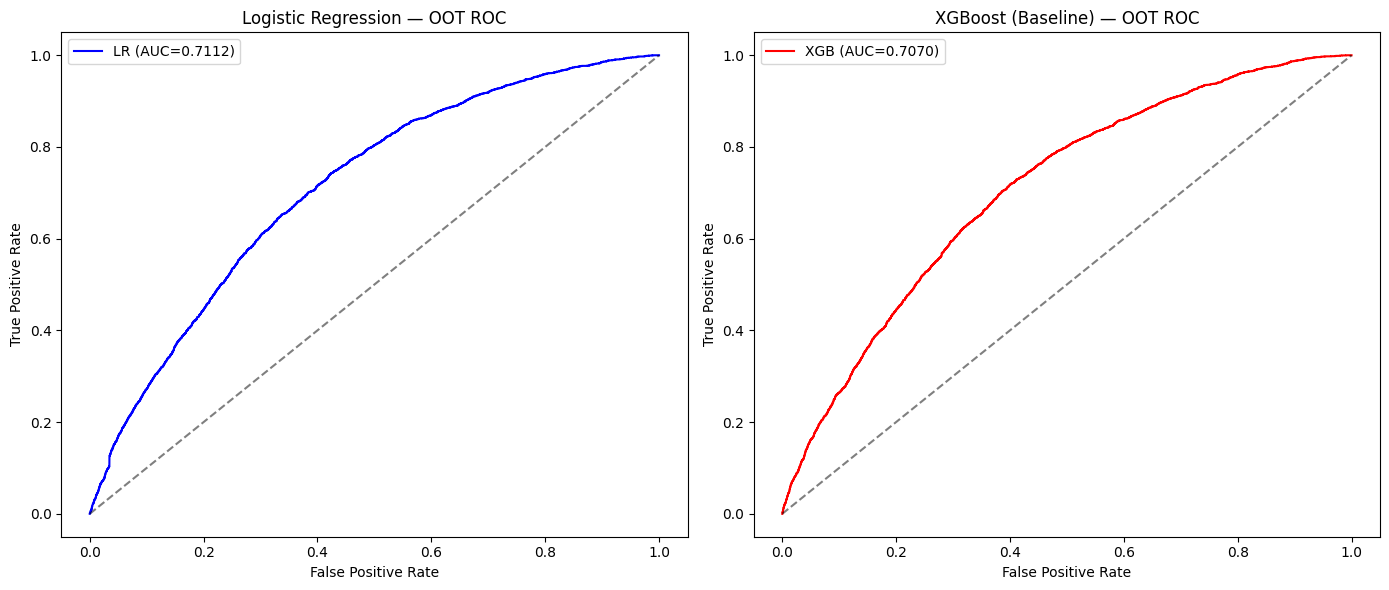

In [12]:

# --- 8.1 Side-by-side comparison ---
print("\n" + "=" * 65)
print("MODEL COMPARISON (OOT Performance)")
print("=" * 65)

comparison = model_comparison_table(lr_aucs, xgb_aucs, lr_cv, xgb_cv)
print(comparison.to_string(index=False))
print("\n--- AUC Interpretation ---")
print("""

Discriminatory Power : AUC
AUC measures the model's ability to rank-order borrowers by default risk. It essentially shows the probability. 

Relative Life
Gini value higher are better.
It shows better our model does than random guessing, it shows what added value our model brings in telling if a customer is good or badd

"""
)




fig = plot_roc_comparison(y_oot, lr_probs_oot, xgb_probs_oot, lr_aucs['oot'], xgb_aucs['oot'])
fig.savefig(PATHS['reports_dir'] / 'figures' / 'roc_comparison.png', dpi=150, bbox_inches='tight')

- Both models have moderate but useful predictive power
- Logistic Regression (WoE) generalises better than XGBoost, although XGBoost can be fine tuned further with Hyperparameter tuning 
- OOT AUC ≈ 0.71 and Gini ≈ 0.42 are acceptable
- XGboost shows slightly worse performance on OOT Sample but still similar to Logistic model. Might be due to overfitting. 

# Calibration of PD

  LR raw AUC: 0.7112 | Gini: 0.4223
  LR platt AUC: 0.7112 | Gini: 0.4223
  LR isotonic AUC: 0.7094 | Gini: 0.4189
  XGB raw AUC: 0.7070 | Gini: 0.4139
  XGB platt AUC: 0.7070 | Gini: 0.4139
  XGB isotonic AUC: 0.7064 | Gini: 0.4127


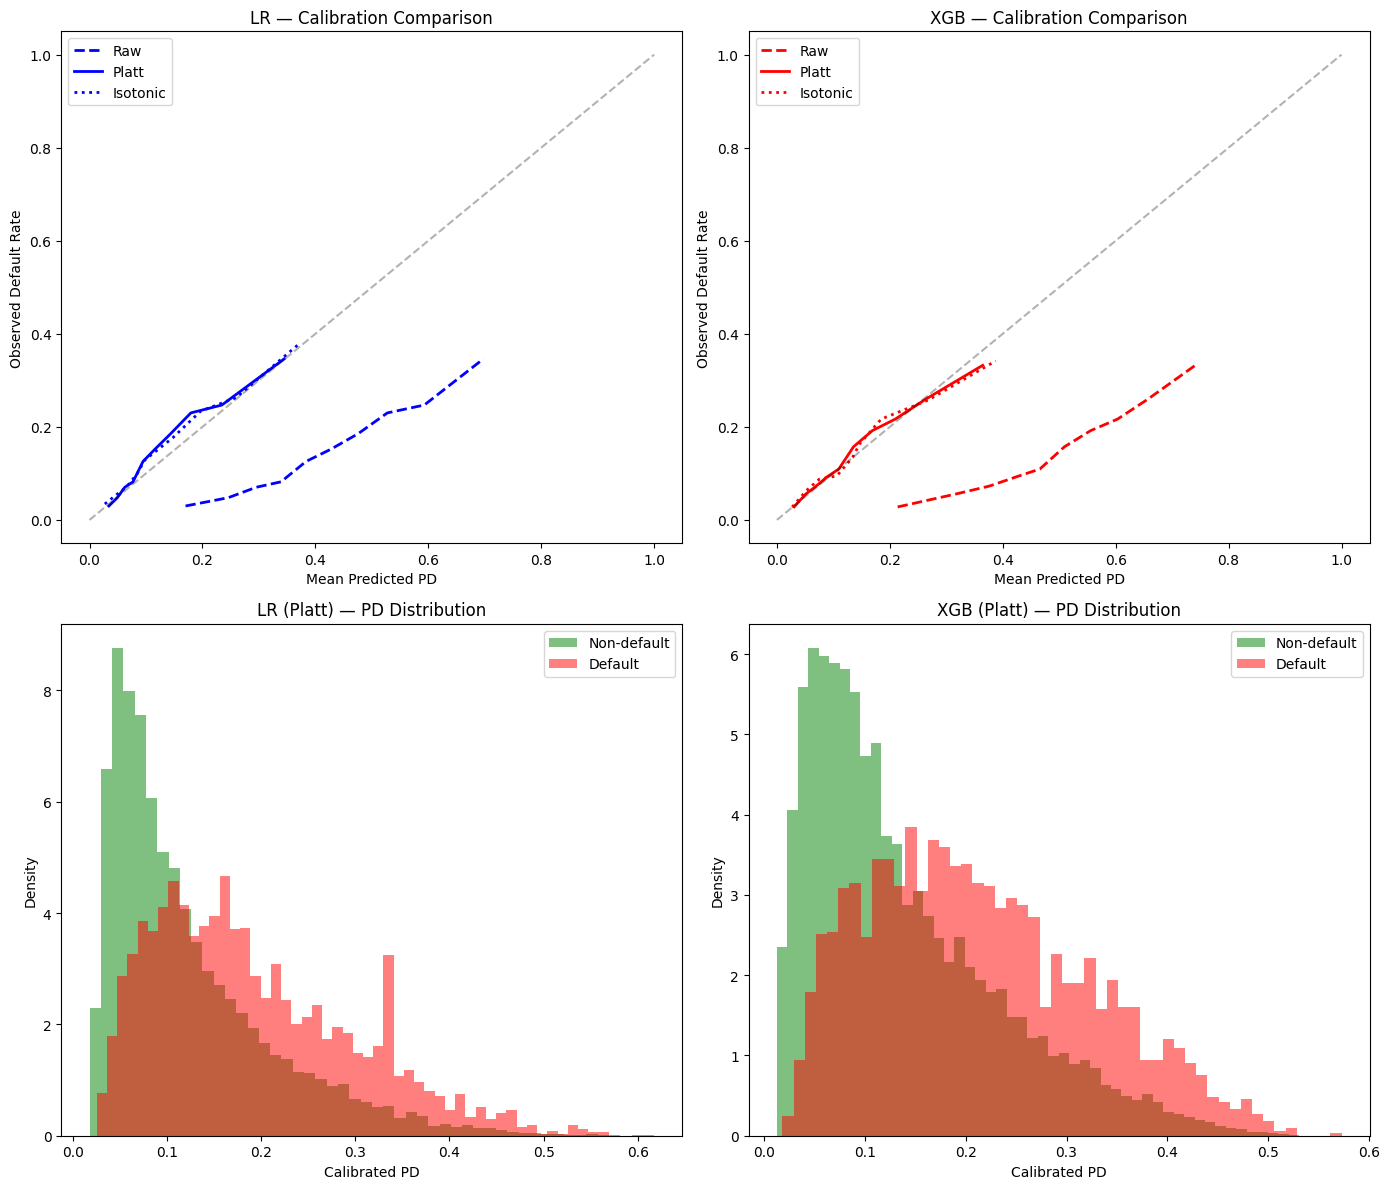

In [13]:
# %%
# Platt scaling (parametric — sigmoid correction)
lr_platt  = fit_platt_scaling(lr_model, X_val_woe, y_val)
xgb_platt = fit_platt_scaling(xgb_model, X_val, y_val)

# Isotonic regression (non-parametric — stepwise correction)
lr_iso  = fit_isotonic(lr_model, X_val_woe, y_val)
xgb_iso = fit_isotonic(xgb_model, X_val, y_val)

# %% [markdown]
# ### 5.3 Apply Calibrators to OOT

# %%
lr_probs_dict = {
    'raw':      lr_probs_oot,
    'platt':    apply_platt(lr_platt, lr_probs_oot),
    'isotonic': apply_isotonic(lr_iso, lr_probs_oot),
}

xgb_probs_dict = {
    'raw':      xgb_probs_oot,
    'platt':    apply_platt(xgb_platt, xgb_probs_oot),
    'isotonic': apply_isotonic(xgb_iso, xgb_probs_oot),
}

# AUC should be identical (calibration is monotonic → ranking unchanged)
for name, probs in lr_probs_dict.items():
    auc, _ = report_auc(y_oot, probs, f"LR {name}")
for name, probs in xgb_probs_dict.items():
    auc, _ = report_auc(y_oot, probs, f"XGB {name}")

# %% [markdown]
# ### 5.4 Calibration Plots

# %%
fig = plot_calibration_comparison(y_oot, lr_probs_dict, xgb_probs_dict)
# fig.savefig(PATHS['reports_dir'] / 'figures' / 'calibration_comparison.png', dpi=150, bbox_inches='tight')


### Brier Score Calibration Assessment


In [14]:


# %%
for name, probs in [('LR (Platt)', lr_probs_dict['platt']),
                     ('XGB (Platt)', xgb_probs_dict['platt'])]:
    
    # Calculate Brier Score
    bs = brier_score_loss(y_oot, probs)
    
    # compare against a "naive" model 
    base_rate = y_oot.mean()
    naive_bs = brier_score_loss(y_oot, [base_rate] * len(y_oot))
    
    # A model is technically 'useful' if it beats the naive Brier Score
    improvement = (naive_bs - bs) / naive_bs * 100
    
    print(f"\n{name} — Brier Score: {bs:.5f}")
    print(f"Improvement over naive model: {improvement:.2f}%")


LR (Platt) — Brier Score: 0.12015
Improvement over naive model: 6.60%

XGB (Platt) — Brier Score: 0.11985
Improvement over naive model: 6.84%


### Hosmer Lemeshow Test

In [15]:
for name, probs in [('LR (Platt)', lr_probs_dict['platt']),
                     ('XGB (Platt)', xgb_probs_dict['platt'])]:
    hl_stat, p_val, hl_summary = hosmer_lemeshow_test(y_oot, probs)
    result = "PASS (well-calibrated)" if p_val >= 0.05 else "FAIL (miscalibrated)"
    print(f"\n{name} — H-L stat: {hl_stat:.2f}, p-value: {p_val:.4f} → {result}")
    print(hl_summary[['n', 'obs_default_rate', 'mean_pred_pd']].to_string())


LR (Platt) — H-L stat: 114.40, p-value: 0.0000 → FAIL (miscalibrated)
                     n  obs_default_rate  mean_pred_pd
decile                                                
(0.0169, 0.0429]  1965          0.030025      0.034379
(0.0429, 0.0557]  1965          0.047837      0.049211
(0.0557, 0.0695]  1964          0.070265      0.062513
(0.0695, 0.0851]  1965          0.081934      0.076970
(0.0851, 0.105]   1964          0.125764      0.094786
(0.105, 0.128]    1965          0.152163      0.116006
(0.128, 0.16]     1964          0.185336      0.143725
(0.16, 0.202]     1965          0.230025      0.179460
(0.202, 0.273]    1964          0.246945      0.234401
(0.273, 0.617]    1965          0.346056      0.344735

XGB (Platt) — H-L stat: 26.56, p-value: 0.0008 → FAIL (miscalibrated)
                     n  obs_default_rate  mean_pred_pd
decile                                                
(0.0115, 0.042]   1965          0.027990      0.030402
(0.042, 0.0606]   1965          0

# Feature Importance 

In [16]:
lr_coef_df = lr_coefficient_table(lr_model, X_train_woe.columns.tolist())
print("\n--- LR Coefficients (Tree based binning) ---")
print(lr_coef_df.to_string(index=False))


--- LR Coefficients (Tree based binning) ---
                              Feature  Coefficient
                 VerificationType_woe    -1.423321
                     LoanDuration_woe     1.374222
                           Gender_woe    -1.037463
                CreditScoreEeMini_woe     0.924890
                        UseOfLoan_woe    -0.752448
                         Interest_woe     0.645678
                           Amount_woe     0.641229
                              Age_woe     0.609746
              ExistingLiabilities_woe    -0.570453
                HomeOwnershipType_woe    -0.563844
                        Education_woe    -0.521105
     PreviousRepaymentsBeforeLoan_woe     0.464319
                 LiabilitiesTotal_woe     0.440297
                   loan_to_income_woe     0.411909
EmploymentDurationCurrentEmployer_woe    -0.373419
                   OccupationArea_woe    -0.323473
  AmountOfPreviousLoansBeforeLoan_woe     0.306970
                    MaritalStatus_wo

### Top Feature for logistic regression : `VerificationType`
<br>
Definition :
Method used for loan application data verification
<br>
Relationship with default:
Direction: Negative
Since the coefficient is -1.423, higher WoE values for verification (typically associated with more rigorous verification) are strongly associated with a lower probability of default.
<br>
Strength: Very Strong
This is the most influential feature in this logistic model.
This probably means the rigorous vertification done is considered less risky by the model which makes sense given the categories in data dictionary.

- 0 Not set
- 1 Income unverified 
- 2 Income unverified, cross-referenced by phone 
- 3 Income verified 
- 4 Income and expenses verified

<br>
As we can see below in distributio chart of the variable majority of customers have category 4 i.e income and expenses verified or second category 1 Income verified. 

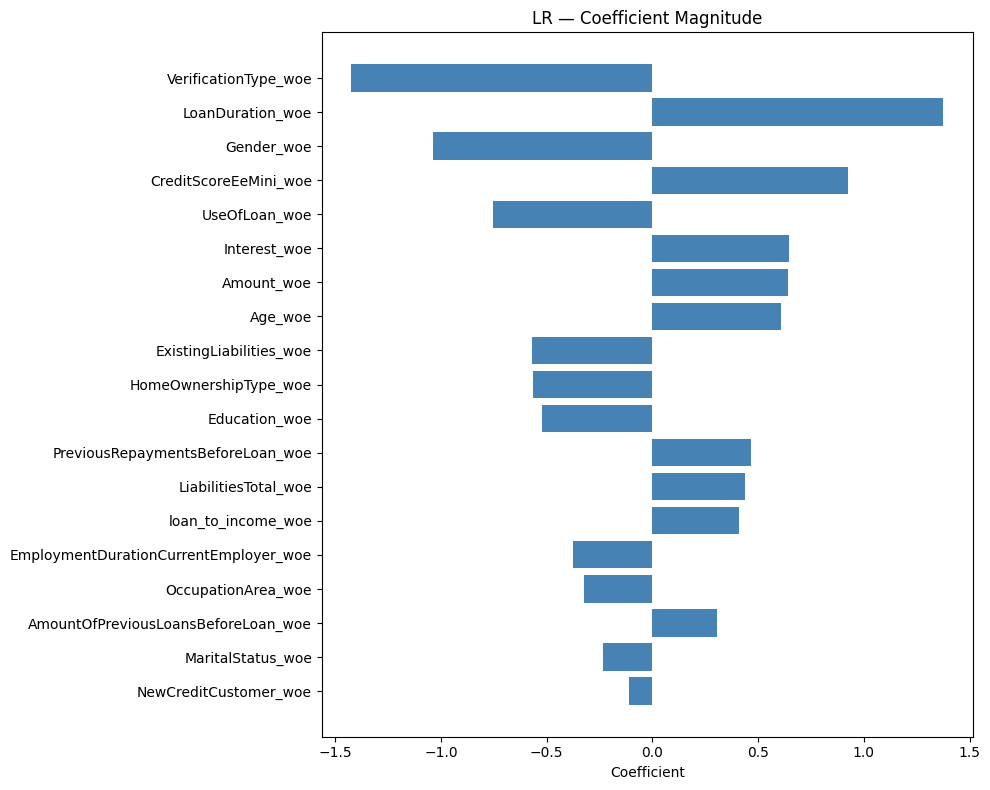

In [17]:
fig = plot_feature_importance(lr_coef_df, title='LR — Coefficient Magnitude', color='steelblue')

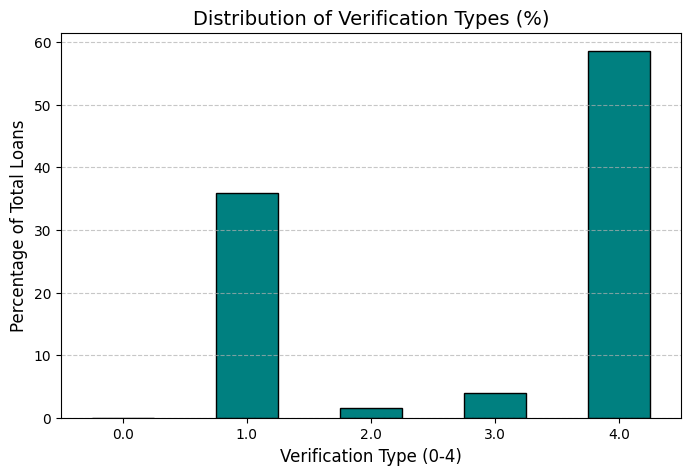

In [18]:
(X_train['VerificationType'].value_counts(normalize=True) * 100).sort_index().plot(
    kind='bar', 
    figsize=(8, 5),
    color='teal',
    edgecolor='black'
)

# Labeling the plot
plt.title('Distribution of Verification Types (%)', fontsize=14)
plt.xlabel('Verification Type (0-4)', fontsize=12)
plt.ylabel('Percentage of Total Loans', fontsize=12)
plt.xticks(rotation=0) # Keeps the 0-4 labels upright
plt.grid(axis='y', linestyle='--', alpha=0.7)

Looking at the Distribution of defaults are concentrated at higher level when income is unverified in category 1 
In category 2 and 3 defaults are still higher but still close enough. 

In Category 4, non-defaults are higher. Thus probably model is predicting risk based on this distribution in the data

Mapping Defaults vs Non-Defaults across Verification Types


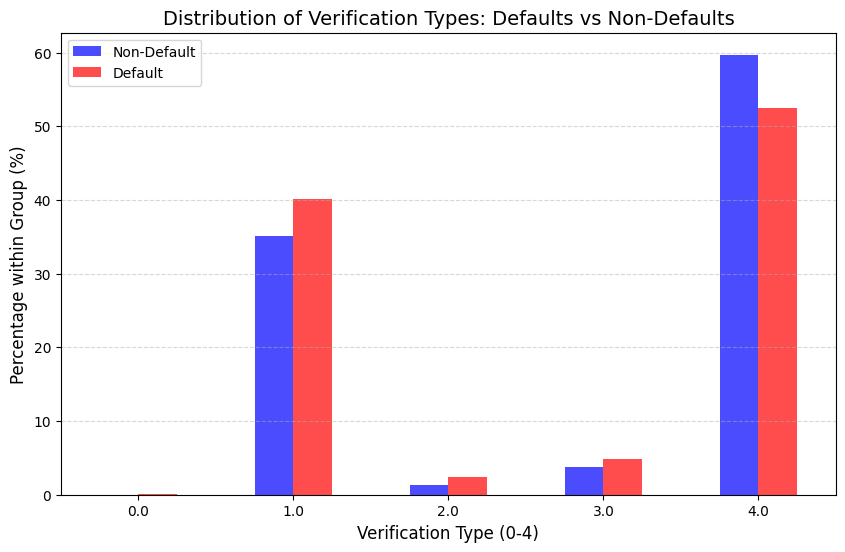

In [19]:
print(f"Mapping Defaults vs Non-Defaults across Verification Types")

# 1. Calculate the distribution of categories for Non-Defaults (y=0)
non_default_dist = X_train[y_train == 0]['VerificationType'].value_counts(normalize=True).sort_index() * 100

# 2. Calculate the distribution of categories for Defaults (y=1)
default_dist = X_train[y_train == 1]['VerificationType'].value_counts(normalize=True).sort_index() * 100

# 3. Combine and plot
df_plot = pd.DataFrame({'Non-Default': non_default_dist, 'Default': default_dist})
df_plot.plot(kind='bar', figsize=(10, 6), color=['blue', 'red'], alpha=0.7)

plt.title('Distribution of Verification Types: Defaults vs Non-Defaults', fontsize=14)
# Label 0: Not set, 1: Unverified, 2: Phone, 3: Income, 4: Income & Expenses
plt.xlabel('Verification Type (0-4)', fontsize=12)
plt.ylabel('Percentage within Group (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

### Top feature (from SHAP / XGBoost gain): `Interest`

**What it is:**
Maximum interest rate accepted in the loan application.

**Relationship with default:**

- *Direction*: Positive
higher interest rates are associated with higher probability of default.

- *Strength*: Strong
Interest is the top feature by both SHAP mean absolute value and XGBoost gain. It contributes more to model predictions than any other single variable.


In [20]:
xgb_imp_df = xgb_importance_table(xgb_model, X_train.columns.tolist())
print("\n--- XGBoost Feature Importance (Gain) ---")
print(xgb_imp_df.head(20).to_string(index=False))


--- XGBoost Feature Importance (Gain) ---
                          Feature  Importance
                         Interest    0.076954
                     LoanDuration    0.058392
                           Gender    0.057321
                CreditScoreEeMini    0.055587
                 VerificationType    0.055530
                NewCreditCustomer    0.048659
                HomeOwnershipType    0.040575
                     LanguageCode    0.037327
PreviousEarlyRepaymentsBefoleLoan    0.035566
                           Amount    0.031188
                        Education    0.030840
                              Age    0.030646
EmploymentDurationCurrentEmployer    0.030167
     PreviousRepaymentsBeforeLoan    0.028131
                   approval_ratio    0.027056
  AmountOfPreviousLoansBeforeLoan    0.024672
                         FreeCash    0.024045
                    MaritalStatus    0.022765
            ApplicationSignedHour    0.020795
                   loan_to_income    

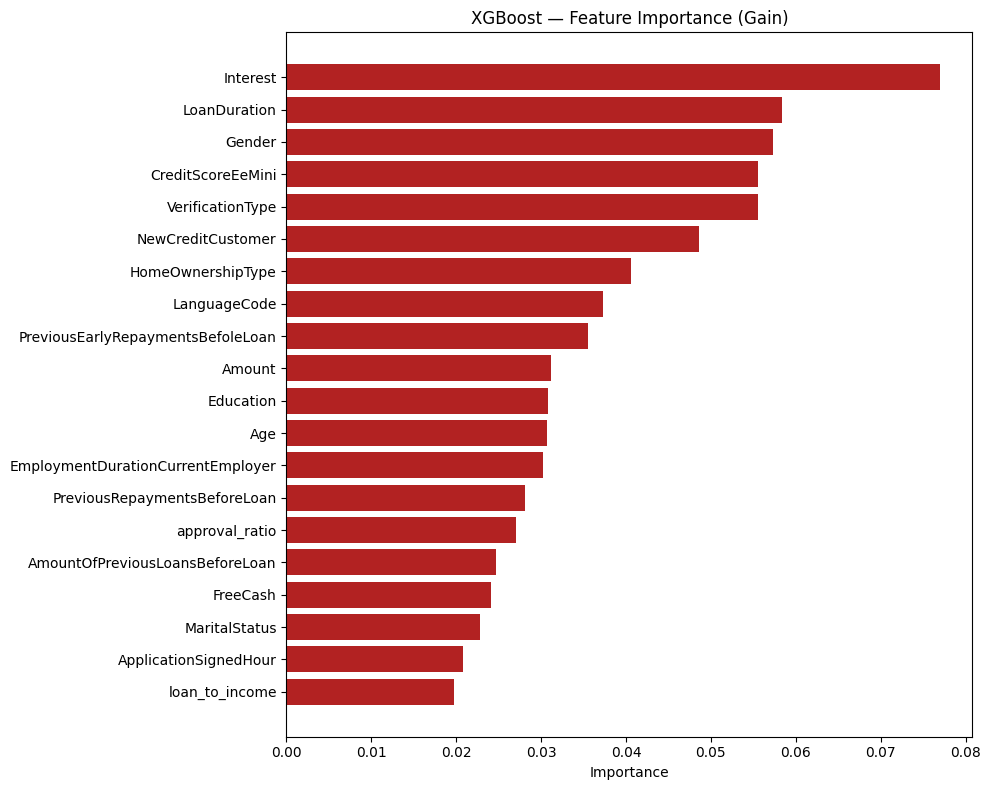

In [21]:
fig = plot_feature_importance(xgb_imp_df, title='XGBoost — Feature Importance (Gain)', color='firebrick')



--- SHAP Feature Importance (XGBoost) ---


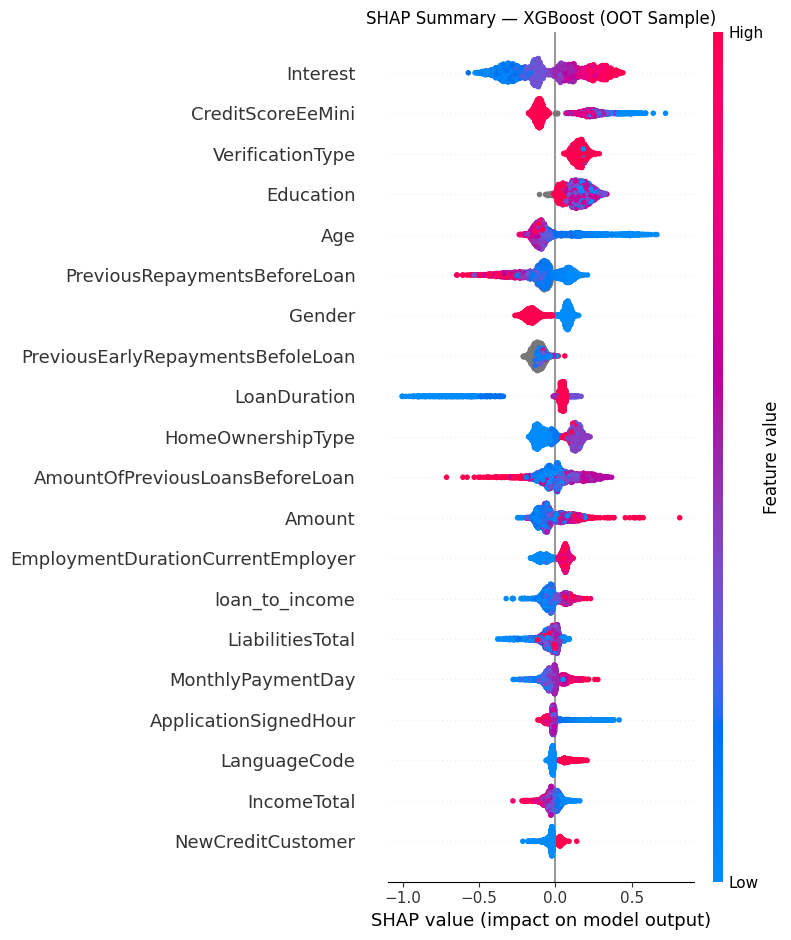

Saved: shap_summary_xgb.png

SHAP Feature Importance (Top 15):
                          Feature  SHAP_mean_abs
                         Interest       0.209516
                CreditScoreEeMini       0.164627
                 VerificationType       0.154692
                        Education       0.139277
                              Age       0.127665
     PreviousRepaymentsBeforeLoan       0.126309
                           Gender       0.117346
PreviousEarlyRepaymentsBefoleLoan       0.115672
                     LoanDuration       0.105619
                HomeOwnershipType       0.104047
  AmountOfPreviousLoansBeforeLoan       0.096793
                           Amount       0.083956
EmploymentDurationCurrentEmployer       0.069634
                   loan_to_income       0.055224
                 LiabilitiesTotal       0.051130


In [22]:
import shap

print("\n--- SHAP Feature Importance (XGBoost) ---")

import json
raw_config = xgb_model.get_booster().save_config()
config = json.loads(raw_config)
config['learner']['learner_model_param']['base_score'] = str(
    float(config['learner']['learner_model_param']['base_score'].strip('[]'))
)
xgb_model.get_booster().load_config(json.dumps(config))




explainer = shap.TreeExplainer(xgb_model)
# Use a sample for speed (full OOT can be slow for large datasets)
shap_sample = X_oot_xgb.sample(n=min(3000, len(X_oot_xgb)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

# SHAP summary plot (shows direction + magnitude)
fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, shap_sample, max_display=20, show=False)
plt.title('SHAP Summary — XGBoost (OOT Sample)')
plt.tight_layout()
# plt.savefig('shap_summary_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_xgb.png")

# SHAP mean absolute importance (for comparison with gain)
shap_importance = pd.DataFrame({
    'Feature': X_oot_xgb.columns,
    'SHAP_mean_abs': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_mean_abs', ascending=False)
print("\nSHAP Feature Importance (Top 15):")
print(shap_importance.head(15).to_string(index=False))

In [23]:
X_train['Interest'].describe()

count    109035.000000
mean         25.352590
std          10.208847
min           2.000000
25%          16.940000
50%          24.280000
75%          33.150000
max          76.080000
Name: Interest, dtype: float64

Distribution of Interest rates


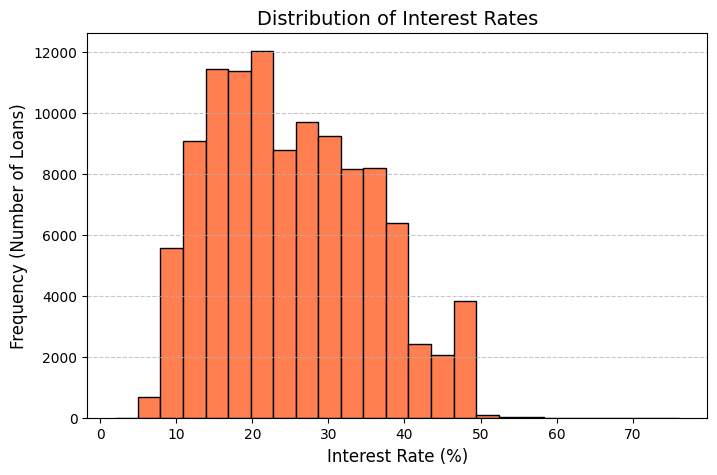

In [24]:
print(f"Distribution of Interest rates")

# Using a histogram for continuous numeric data
X_train['Interest'].plot(
    kind='hist', 
    bins=25, 
    figsize=(8, 5), 
    color='coral', 
    edgecolor='black'
)

plt.title('Distribution of Interest Rates', fontsize=14)
plt.xlabel('Interest Rate (%)', fontsize=12)
plt.ylabel('Frequency (Number of Loans)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

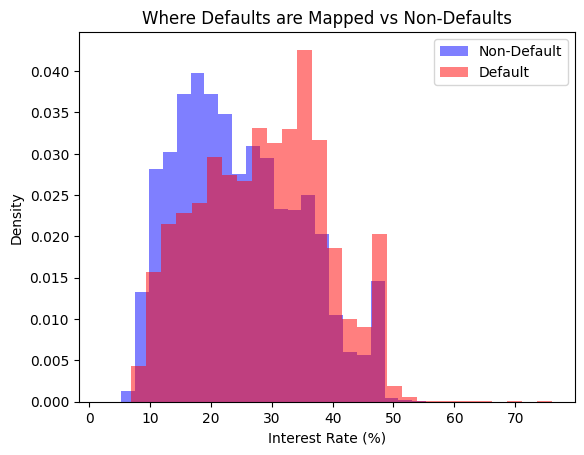

In [25]:
# Plotting Non-Defaults (y=0)
X_train[y_train == 0]['Interest'].plot(
    kind='hist', bins=30, alpha=0.5, label='Non-Default', color='blue', density=True
)

# Plotting Defaults (y=1)
X_train[y_train == 1]['Interest'].plot(
    kind='hist', bins=30, alpha=0.5, label='Default', color='red', density=True
)

plt.title('Where Defaults are Mapped vs Non-Defaults')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Density')
plt.legend()

# Chosen model to further work on : XGboost

Reasons :
- Both the models have similar discriminatory power. the OOT gap is very small. 
- AUC drop for XGboost from Train to OOT drop 0.7618 → 0.7070 suggests overfitting and can be fixed with regularization
- XGboost wins on calibration. Hosmer-Lemeshow test (lower value is better) shows  better calibration compared to LR. 
- XGBoost's calibration error is 4× smaller than LR's in HL test. Brier Score tells the same story: XGB 0.11985 vs LR 0.12015 
- Dropping features with suspected leakage may hurt LR more than XGBoost. 
- Difference in cross validation standard deviation for both models is trivial. 
- With Shap values we also have interpretability 

**Although for ease of deployment logistic would be ideal, also in api when outputting featuers by importance per prediction it will be easy to interpret what resulting in the customer to get the PD it got

Hyper-Parameter Tuning XGBoost

 Optuna Hyperparameter Search (XGBoost)

In [26]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
def objective(trial):
    params = {
        # --- Tree structure ---
        "max_depth":          trial.suggest_int("max_depth", 3, 7),
        "min_child_weight":   trial.suggest_int("min_child_weight", 5, 100),

        # --- Learning rate & ensemble size ---
        "n_estimators":       trial.suggest_int("n_estimators", 200, 1000, step=100),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.15, log=True),

        # --- Stochastic subsampling (reduces overfitting) ---
        "subsample":          trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel":  trial.suggest_float("colsample_bylevel", 0.5, 1.0),

        # --- L1 / L2 regularisation ---
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),

        # --- Fixed settings (carry over from baseline model) ---
        "scale_pos_weight":   imbalance_ratio,
        "eval_metric":        "auc",
        "tree_method":        "hist",
        "random_state":       RANDOM_STATE,
        "verbosity":          0,
    }

    model = xgb.XGBClassifier(**params, early_stopping_rounds=30)
    model.fit(
        X_train_xgb, y_train,
        eval_set=[(X_val_xgb, y_val)],
        verbose=False,
    )
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val_xgb)[:, 1])
    return val_auc


N_TRIALS = 75   # increase to 150+ for production; ~75 is a good demo run

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="xgb_pd_model",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest Val AUC : {study.best_value:.4f}")
print(f"Best params  : {study.best_params}")

  0%|          | 0/75 [00:00<?, ?it/s]


Best Val AUC : 0.7512
Best params  : {'max_depth': 4, 'min_child_weight': 58, 'n_estimators': 300, 'learning_rate': 0.06239747738093842, 'subsample': 0.7515893999826997, 'colsample_bytree': 0.5021551154312816, 'colsample_bylevel': 0.6654574133857494, 'reg_alpha': 0.18443586934099537, 'reg_lambda': 0.036430105204737814}


In [28]:
best_params = study.best_params.copy()

xgb_tuned = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=imbalance_ratio,
    eval_metric="auc",
    tree_method="hist",
    random_state=RANDOM_STATE,
    verbosity=0,
)
xgb_tuned.fit(X_train, y_train, verbose=False)

print(f"Tuned XGBoost trained on {len(y_train):,} rows.")

Tuned XGBoost trained on 109,035 rows.


### Compare baseline vs Tuned Model (XGBoost)

In [29]:
xgb_tuned_probs_train = xgb_tuned.predict_proba(X_train_xgb)[:, 1]
xgb_tuned_probs_val   = xgb_tuned.predict_proba(X_val_xgb)[:, 1]
xgb_tuned_probs_oot   = xgb_tuned.predict_proba(X_oot_xgb)[:, 1]


xgb_tuned_aucs = report_auc_all(
    y_train, xgb_tuned_probs_train,
    y_val,   xgb_tuned_probs_val,
    y_oot,   xgb_tuned_probs_oot,
    model_name="XGBoost Tuned",
)

# Quick side-by-side summary
print("\n" + "=" * 55)
print(f"{'Metric':<20} {'Baseline':>15} {'Tuned':>15}")
print("=" * 55)
for split in ['train', 'val', 'oot']:
    base_auc  = xgb_aucs[split]
    tuned_auc = xgb_tuned_aucs[split]
    delta     = tuned_auc - base_auc
    print(f"AUC {split.upper():<15} {base_auc:>15.4f} {tuned_auc:>15.4f}  (Δ {delta:+.4f})")
print("-" * 55)
for split in ['train', 'val', 'oot']:
    base_gini  = 2 * xgb_aucs[split]  - 1
    tuned_gini = 2 * xgb_tuned_aucs[split] - 1
    print(f"Gini {split.upper():<14} {base_gini:>15.4f} {tuned_gini:>15.4f}")
print("=" * 55)


--- XGBoost Tuned Performance ---
  Train AUC: 0.7576 | Gini: 0.5151
  Val   AUC: 0.7512 | Gini: 0.5025
  OOT   AUC: 0.7050 | Gini: 0.4100

Metric                      Baseline           Tuned
AUC TRAIN                    0.7618          0.7576  (Δ -0.0042)
AUC VAL                      0.7475          0.7512  (Δ +0.0037)
AUC OOT                      0.7070          0.7050  (Δ -0.0020)
-------------------------------------------------------
Gini TRAIN                   0.5235          0.5151
Gini VAL                     0.4950          0.5025
Gini OOT                     0.4139          0.4100


Actually performance didn't improve significantly, still OOT auc is around ~70%. 
Probably OOT period is a culprit of population drif, maybe engineering more new features can provide better performance compared to current features. or running hyperparametrization for 150+ N trials.

### Recalibrate Tuned XGBoost Model

In [30]:

xgb_tuned_platt = fit_platt_scaling(xgb_tuned, X_val_xgb, y_val)
xgb_tuned_probs_oot_cal = apply_platt(xgb_tuned_platt, xgb_tuned_probs_oot)

# Brier score comparison
from sklearn.metrics import brier_score_loss
bs_baseline = brier_score_loss(y_oot, apply_platt(xgb_platt, xgb_probs_oot))
bs_tuned    = brier_score_loss(y_oot, xgb_tuned_probs_oot_cal)
print(f"\nBrier Score — Baseline (calibrated): {bs_baseline:.5f}")
print(f"Brier Score — Tuned   (calibrated): {bs_tuned:.5f}")
print(f"Improvement: {(bs_baseline - bs_tuned) / bs_baseline * 100:+.2f}%")

# Hosmer-Lemeshow on tuned model
hl_stat, p_val, _ = hosmer_lemeshow_test(y_oot, xgb_tuned_probs_oot_cal)
result = "PASS (well-calibrated)" if p_val >= 0.05 else "FAIL (miscalibrated)"
print(f"\nH-L test (Tuned, calibrated): stat={hl_stat:.2f}, p={p_val:.4f} → {result}")


Brier Score — Baseline (calibrated): 0.11985
Brier Score — Tuned   (calibrated): 0.11979
Improvement: +0.05%

H-L test (Tuned, calibrated): stat=53.05, p=0.0000 → FAIL (miscalibrated)


### Top variables: relationship with default


--- SHAP Feature Importance (XGBoost Tuned) ---


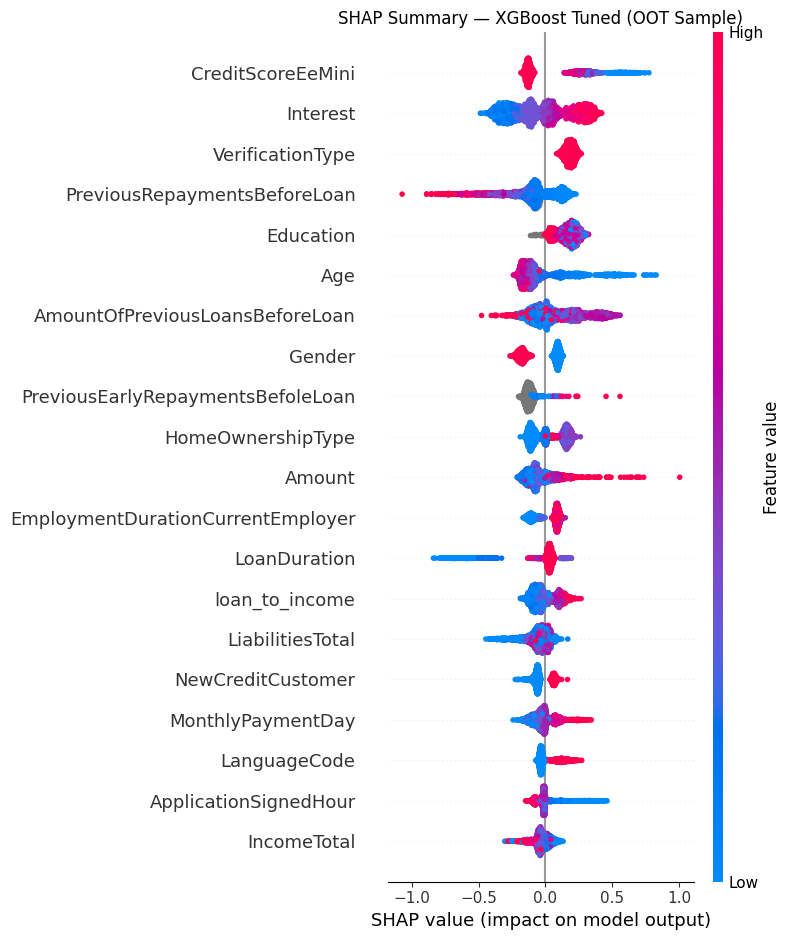

In [31]:
print("\n--- SHAP Feature Importance (XGBoost Tuned) ---")

explainer_tuned = shap.TreeExplainer(xgb_tuned)
shap_sample_tuned = X_oot_xgb.sample(n=min(3000, len(X_oot_xgb)), random_state=42)
shap_values_tuned = explainer_tuned.shap_values(shap_sample_tuned)

fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values_tuned, shap_sample_tuned, max_display=20, show=False)
plt.title("SHAP Summary — XGBoost Tuned (OOT Sample)")
plt.tight_layout()
plt.savefig(PATHS['reports_dir'] / 'figures' / 'shap_summary_xgb_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

### Since model didn't show much improvement and ease of implementation I am picking logistic regression for deployment testing. to showcase how the model works in deployment by using the model file and creating an endpoint using fastapi 



# Export Model

In [34]:
models_dir = PATHS['models_dir']
models_dir.mkdir(parents=True, exist_ok=True)

# Models - Baseline
joblib.dump(lr_model, models_dir / 'lr_model.joblib')
joblib.dump(xgb_model, models_dir / 'xgb_model.joblib')

# Calibrated - Baseline Models
joblib.dump(lr_platt, models_dir / 'lr_platt_calibrator.joblib')
joblib.dump(xgb_platt, models_dir / 'xgb_platt_calibrator.joblib')

# Tuned XGBoost — this is the production model
joblib.dump(xgb_tuned,         models_dir / 'xgb_model_tuned.joblib')
joblib.dump(xgb_tuned_platt,   models_dir / 'xgb_tuned_platt_calibrator.joblib')

print(f"\n✓ Models saved to {models_dir}/")


✓ Models saved to /home/me/Documents/Coding/Projects/pd_model/models/
